In [1]:
! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis


In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import numpy as np
from datetime import datetime
import cftime

In [5]:
df = pd.read_csv('/Users/jamerafernando/Desktop/PA3/DSC-106-Project-4/drought_agg.csv')

In [8]:
historical = df[
    (df["experiment"] == "historical") &
    (df["continent"] != "Ocean / Unclassified")
]
historical.head()

,year,experiment,climate_zone,continent,mean_spi,pct_drought,pct_severe,record_freq,max_streak
19,1850,historical,Polar,Antarctica,-0.0714,0.1898,0.0046,1.0,1
20,1850,historical,Polar,Asia,-0.3716,0.2414,0.0000,1.0,1
21,1850,historical,Polar,Europe,-0.8082,0.3182,0.0909,1.0,1
22,1850,historical,Polar,North America,-0.2920,0.2438,0.0188,1.0,1
24,1850,historical,Temperate,Africa,0.3812,0.0222,0.0000,1.0,1


In [7]:
historical.groupby("continent")["drought_index"].mean().sort_values(ascending=False).plot(kind="bar")

KeyError: 'Column not found: drought_index'

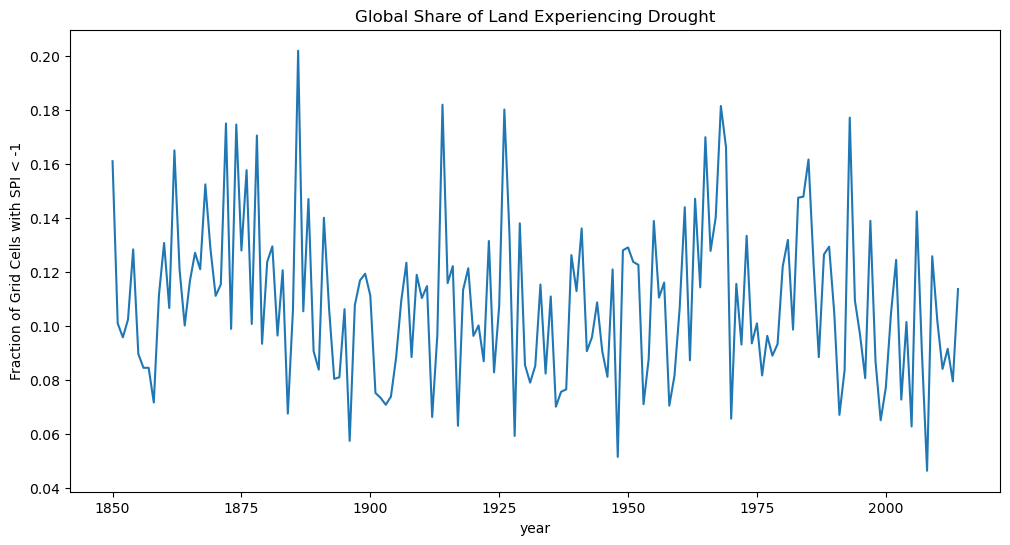

In [10]:
global_drought = (
    historical
    .groupby("year")
    .agg(
        pct_drought=("pct_drought","mean")
    )
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=global_drought,
    x="year",
    y="pct_drought"
)

plt.title("Global Share of Land Experiencing Drought")
plt.ylabel("Fraction of Grid Cells with SPI < -1")
plt.show()

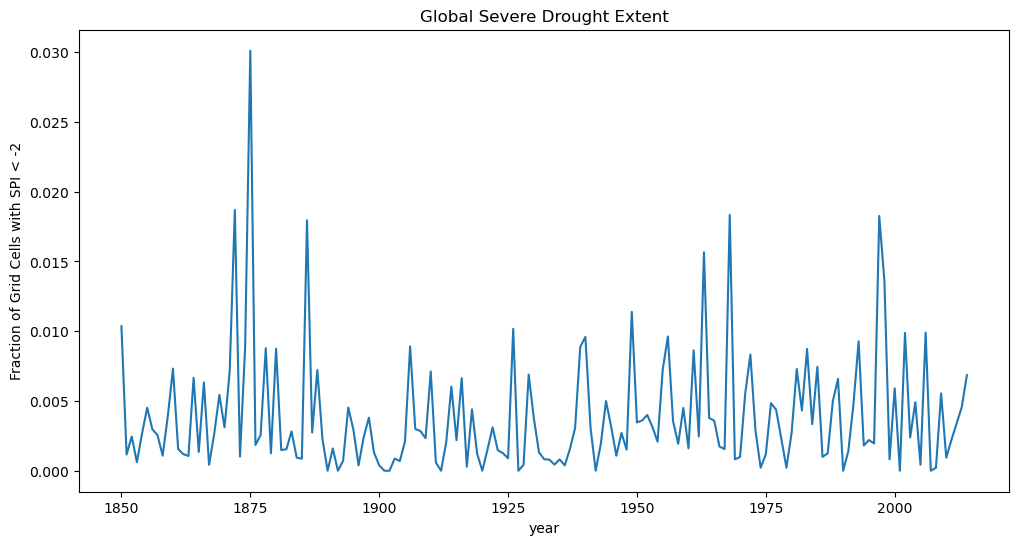

In [12]:
global_severe = (
    historical
    .groupby("year")
    .agg(
        pct_severe=("pct_severe","mean")
    )
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=global_severe,
    x="year",
    y="pct_severe"
)

plt.title("Global Severe Drought Extent")
plt.ylabel("Fraction of Grid Cells with SPI < -2")
plt.show()

<Axes: xlabel='year', ylabel='pct_drought'>

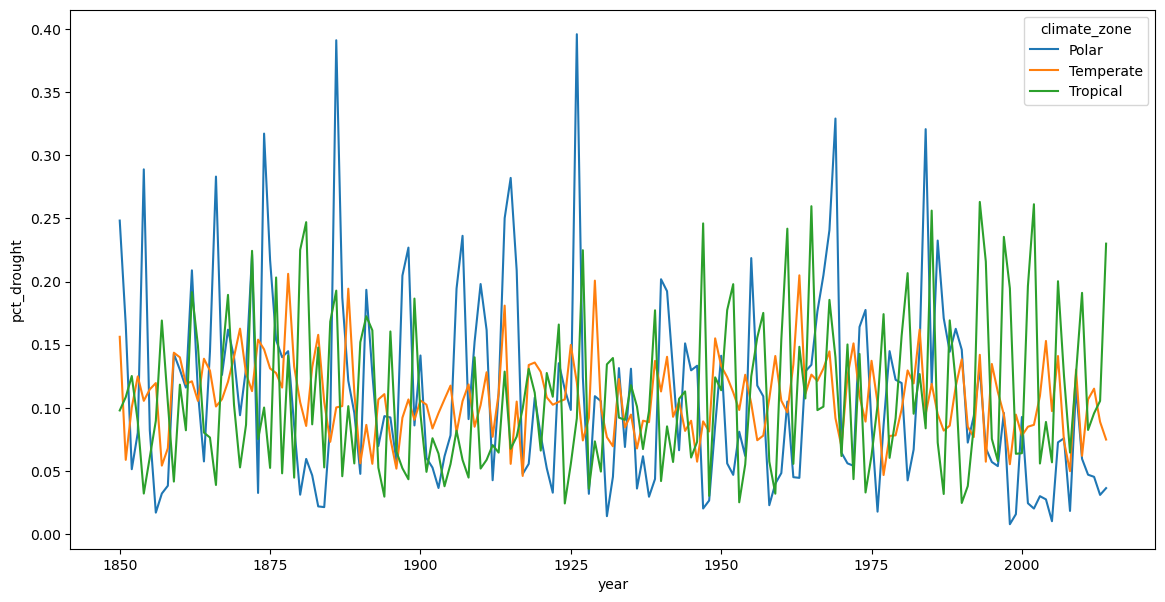

In [14]:
zone = (
    historical
    .groupby(["year","climate_zone"])
    .agg(
        pct_drought=("pct_drought","mean")
    )
    .reset_index()
)
plt.figure(figsize=(14,7))

sns.lineplot(
    data=zone,
    x="year",
    y="pct_drought",
    hue="climate_zone"
)

/var/folders/s3/m4b8711x1pd7xs7pyxpr_r9w0000gn/T/ipykernel_1554/2737104502.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  historical["decade"] = (


<Axes: xlabel='continent', ylabel='pct_drought'>

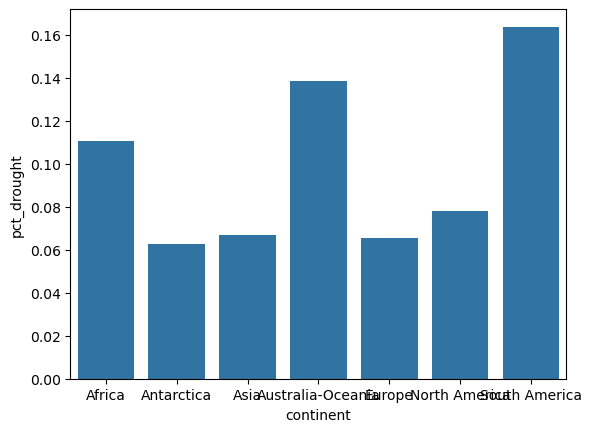

In [16]:
historical["decade"] = (
    historical["year"] // 10
) * 10

continent_decade = (
    historical
    .groupby(["decade","continent"])
    .agg(
        pct_drought=("pct_drought","mean")
    )
    .reset_index()
)

sns.barplot(
    data=continent_decade[
        continent_decade["decade"] == 2000
    ],
    x="continent",
    y="pct_drought"
)

/var/folders/s3/m4b8711x1pd7xs7pyxpr_r9w0000gn/T/ipykernel_1554/68579664.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  historical["decade"] = (historical["year"] // 10) * 10


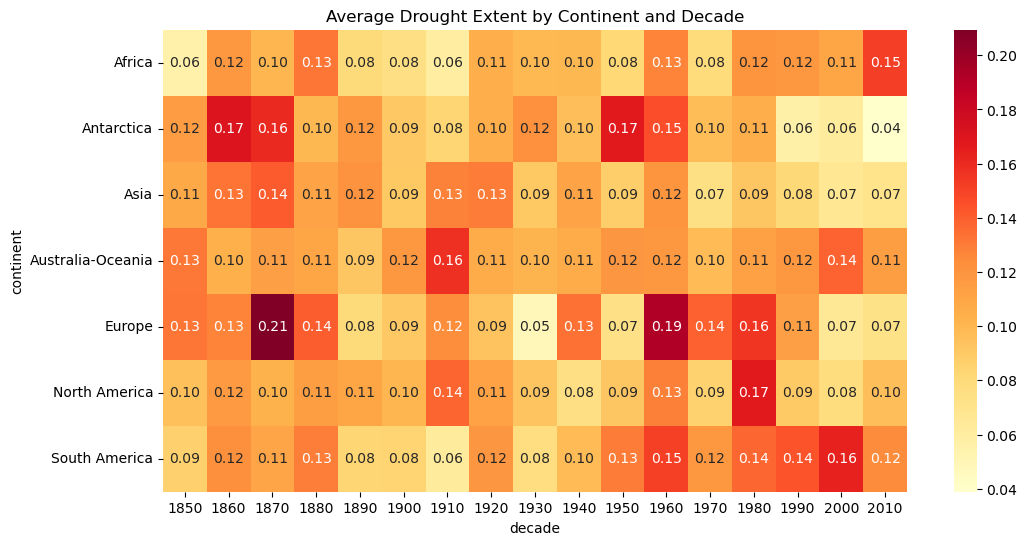

In [21]:
historical["decade"] = (historical["year"] // 10) * 10

heat_decade = (
    historical
    .groupby(["continent", "decade"])
    .agg(
        pct_drought=("pct_drought", "mean")
    )
    .reset_index()
    .pivot(
        index="continent",
        columns="decade",
        values="pct_drought"
    )
)

plt.figure(figsize=(12,6))

sns.heatmap(
    heat_decade,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f"
)

plt.title("Average Drought Extent by Continent and Decade")
plt.show()


/var/folders/s3/m4b8711x1pd7xs7pyxpr_r9w0000gn/T/ipykernel_1554/2311215488.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  historical["decade"] = (historical["year"] // 10) * 10


<Axes: xlabel='decade', ylabel='continent'>

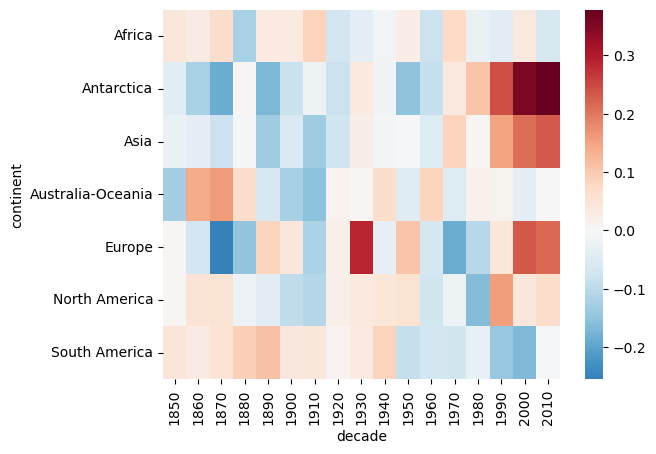

In [24]:
historical["decade"] = (historical["year"] // 10) * 10

heat_spi = (
    historical
    .groupby(["continent","decade"])
    .agg(
        mean_spi=("mean_spi","mean")
    )
    .reset_index()
    .pivot(
        index="continent",
        columns="decade",
        values="mean_spi"
    )
)

sns.heatmap(
    heat_spi,
    center=0,
    cmap="RdBu_r"
)



<Axes: xlabel='decade', ylabel='continent'>

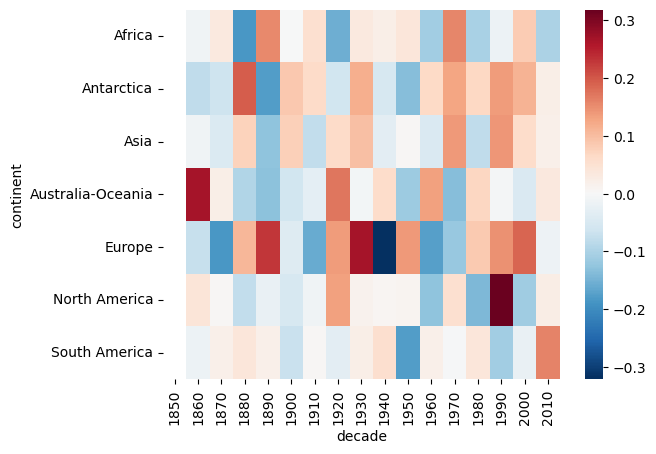

In [30]:
spi_change = (
    heat_spi.diff(axis=1)
)
sns.heatmap(
    spi_change,
    center=0,
    cmap="RdBu_r"
)


In [ ]:
historical[
    hichange_mag = abs(spi_change)storical["continent"]=="North America"
]

In [31]:
historical[
    historical["continent"]=="North America"
]

,year,experiment,climate_zone,continent,mean_spi,pct_drought,pct_severe,record_freq,max_streak,decade
22,1850,historical,Polar,North America,-0.2920,0.2438,0.0188,1.0000,1,1850
29,1850,historical,Temperate,North America,0.0361,0.1318,0.0000,1.0000,1,1850
35,1850,historical,Tropical,North America,-0.0012,0.1667,0.0000,1.0000,1,1850
60,1851,historical,Polar,North America,-0.4776,0.1938,0.0125,0.5562,2,1850
67,1851,historical,Temperate,North America,0.1532,0.0338,0.0000,0.4628,2,1850
...,...,...,...,...,...,...,...,...,...,...
5976,2013,historical,Temperate,North America,0.2158,0.1385,0.0439,0.0372,1,2010
5982,2013,historical,Tropical,North America,0.2169,0.1042,0.0000,0.0000,0,2010
5988,2014,historical,Polar,North America,0.3401,0.0312,0.0000,0.0000,0,2010
5995,2014,historical,Temperate,North America,0.0531,0.1419,0.0135,0.0203,1,2010


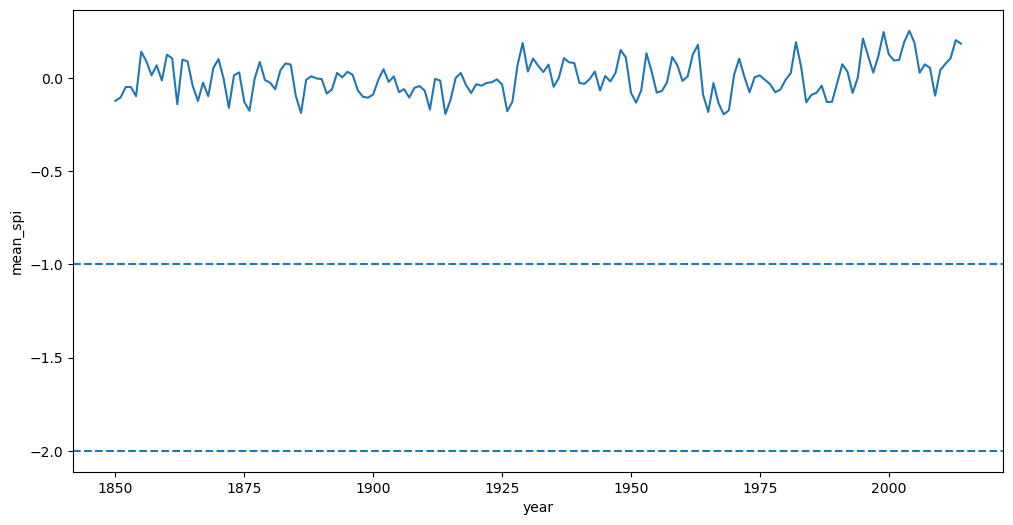

In [18]:
spi = (
    historical
    .groupby("year")
    .agg(
        mean_spi=("mean_spi","mean")
    )
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=spi,
    x="year",
    y="mean_spi"
)

plt.axhline(-1, linestyle="--")
plt.axhline(-2, linestyle="--")

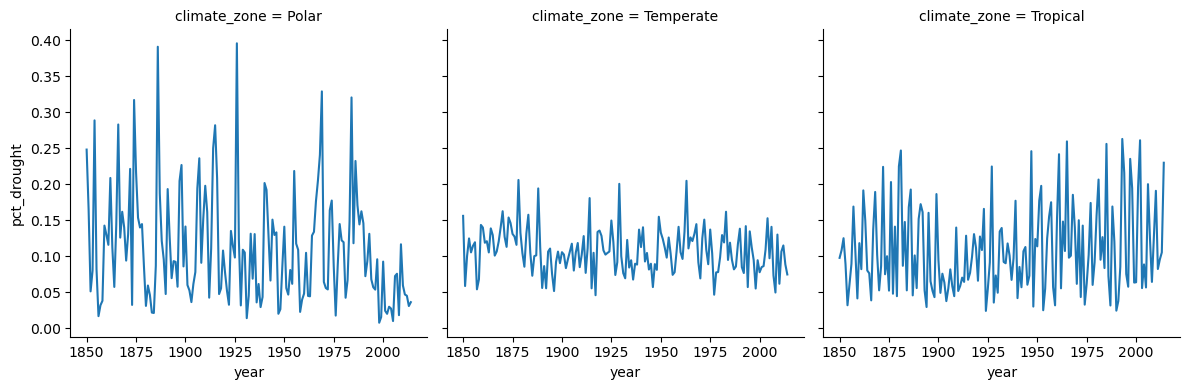

In [19]:
g = sns.FacetGrid(
    zone,
    col="climate_zone",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.lineplot,
    x="year",
    y="pct_drought"
)

<Axes: xlabel='year', ylabel='max_streak'>

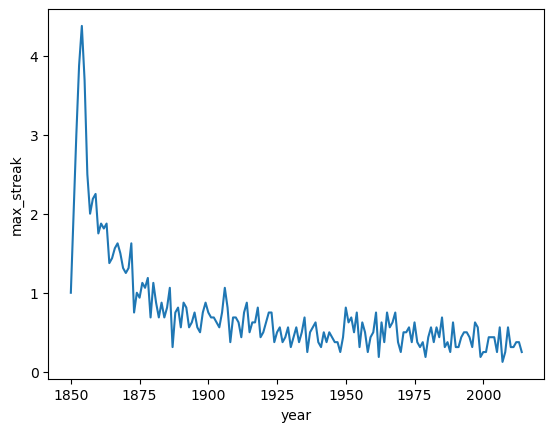

In [20]:
streak = (
    historical
    .groupby("year")
    .agg(
        max_streak=("max_streak","mean")
    )
    .reset_index()
)

sns.lineplot(
    data=streak,
    x="year",
    y="max_streak"
)
